In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

print("Libraries loaded successfully.")


Libraries loaded successfully.


In [35]:
from pathlib import Path

DATA_PATH = Path("../../data/raw/creditcard.csv")

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

Dataset loaded successfully.
Rows: 284,807
Columns: 31


In [36]:
TARGET = "Class"

print("Target column:", TARGET)
print("Unique target values:", sorted(df[TARGET].unique()))
print("\nTarget value counts:")
print(df[TARGET].value_counts().sort_index())

Target column: Class
Unique target values: [np.int64(0), np.int64(1)]

Target value counts:
Class
0    284315
1       492
Name: count, dtype: int64


Calculate the class distribution

In [37]:
class_counts = df[TARGET].value_counts().sort_index()

legitimate_count = class_counts.get(0, 0)
fraud_count = class_counts.get(1, 0)
total_transactions = len(df)

legitimate_percentage = legitimate_count / total_transactions * 100
fraud_percentage = fraud_count / total_transactions * 100

print("=" * 50)
print("CLASS DISTRIBUTION")
print("=" * 50)

print(f"Total transactions : {total_transactions:,}")
print(f"Legitimate         : {legitimate_count:,}")
print(f"Fraudulent         : {fraud_count:,}")

print()
print(f"Legitimate rate    : {legitimate_percentage:.4f}%")
print(f"Fraud rate         : {fraud_percentage:.4f}%")

CLASS DISTRIBUTION
Total transactions : 284,807
Legitimate         : 284,315
Fraudulent         : 492

Legitimate rate    : 99.8273%
Fraud rate         : 0.1727%


Calculate the imbalance ratio


In [38]:
if fraud_count == 0:
    raise ValueError("No fraudulent transactions found in the dataset.")

imbalance_ratio = legitimate_count / fraud_count

print(f"Imbalance ratio: {imbalance_ratio:.2f}:1")

Imbalance ratio: 577.88:1


Visualize the imbalance

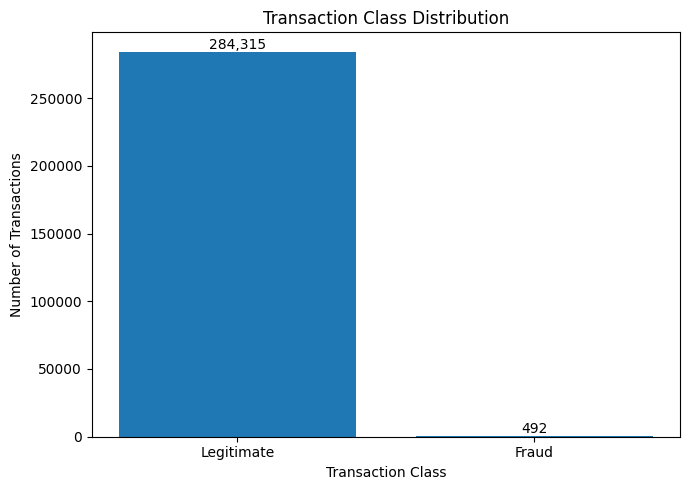

In [39]:
labels = ["Legitimate", "Fraud"]
values = [legitimate_count, fraud_count]

plt.figure(figsize=(7, 5))
plt.bar(labels, values)

plt.title("Transaction Class Distribution")
plt.ylabel("Number of Transactions")
plt.xlabel("Transaction Class")

for i, value in enumerate(values):
    plt.text(i, value, f"{value:,}", ha="center", va="bottom")

plt.tight_layout()
plt.show()

## Class Imbalance Findings

The dataset contains 284,807 transactions:

- 284,315 legitimate transactions (99.8273%)
- 492 fraudulent transactions (0.1727%)
- Class imbalance ratio: approximately 577.88:1

This represents an extreme class imbalance problem. Accuracy alone is therefore
not an appropriate metric for evaluating fraud detection performance.

Model evaluation will focus primarily on precision, recall, F1-score, PR-AUC,
ROC-AUC, confusion matrices, false positives, and false negatives.

Any resampling technique will be applied only to training data and, during
cross-validation, only within the corresponding training fold to prevent data
leakage.

## Duplicate Transaction Investigation

The next step investigates exact duplicate rows before making any cleaning
decision. Duplicates are not removed automatically because repeated
transactions may be legitimate observations, and removing duplicated fraud
cases could materially affect the minority class.

In [40]:
duplicate_count = df.duplicated().sum()
duplicate_percentage = duplicate_count / len(df) * 100

print("=" * 50)
print("DUPLICATE ANALYSIS")
print("=" * 50)

print(f"Total rows           : {len(df):,}")
print(f"Duplicate rows       : {duplicate_count:,}")
print(f"Duplicate percentage : {duplicate_percentage:.4f}%")

DUPLICATE ANALYSIS
Total rows           : 284,807
Duplicate rows       : 1,081
Duplicate percentage : 0.3796%


Separate duplicated rows


In [41]:
duplicate_rows = df[df.duplicated(keep="first")].copy()

print(f"Additional duplicate copies: {len(duplicate_rows):,}")

duplicate_rows.head()

Additional duplicate copies: 1,081


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
33,26.0,-0.529912,0.873892,1.347247,0.145457,0.414209,0.100223,0.711206,0.176066,-0.286717,-0.484688,0.872490,0.851636,-0.571745,0.100974,-1.519772,-0.284376,-0.310524,-0.404248,-0.823374,-0.290348,0.046949,0.208105,-0.185548,0.001031,0.098816,-0.552904,-0.073288,0.023307,6.14,0
35,26.0,-0.535388,0.865268,1.351076,0.147575,0.433680,0.086983,0.693039,0.179742,-0.285642,-0.482474,0.871800,0.853447,-0.571822,0.102252,-1.519991,-0.285912,-0.309633,-0.403902,-0.823743,-0.283264,0.049526,0.206537,-0.187108,0.000753,0.098117,-0.553471,-0.078306,0.025427,1.77,0
113,74.0,1.038370,0.127486,0.184456,1.109950,0.441699,0.945283,-0.036715,0.350995,0.118950,-0.243289,0.578063,0.674730,-0.534231,0.446601,1.122885,-1.768001,1.241157,-2.449500,-1.747255,-0.335520,0.102520,0.605089,0.023092,-0.626463,0.479120,-0.166937,0.081247,0.001192,1.18,0
114,74.0,1.038370,0.127486,0.184456,1.109950,0.441699,0.945283,-0.036715,0.350995,0.118950,-0.243289,0.578063,0.674730,-0.534231,0.446601,1.122885,-1.768001,1.241157,-2.449500,-1.747255,-0.335520,0.102520,0.605089,0.023092,-0.626463,0.479120,-0.166937,0.081247,0.001192,1.18,0
115,74.0,1.038370,0.127486,0.184456,1.109950,0.441699,0.945283,-0.036715,0.350995,0.118950,-0.243289,0.578063,0.674730,-0.534231,0.446601,1.122885,-1.768001,1.241157,-2.449500,-1.747255,-0.335520,0.102520,0.605089,0.023092,-0.626463,0.479120,-0.166937,0.081247,0.001192,1.18,0


In [42]:
df.duplicated(keep=False)

0         False
1         False
2         False
3         False
4         False
          ...  
284802    False
284803    False
284804    False
284805    False
284806    False
Length: 284807, dtype: bool

In [43]:
all_duplicated_rows = df[df.duplicated(keep=False)].copy()

print(
    f"All rows belonging to duplicate groups: "
    f"{len(all_duplicated_rows):,}"
)

All rows belonging to duplicate groups: 1,854


Most important check: duplicates by class

In [44]:
duplicate_class_counts = (
    duplicate_rows["Class"]
    .value_counts()
    .sort_index()
)

duplicate_legitimate = duplicate_class_counts.get(0, 0)
duplicate_fraud = duplicate_class_counts.get(1, 0)

print("=" * 50)
print("DUPLICATE ROWS BY CLASS")
print("=" * 50)

print(f"Duplicate legitimate rows : {duplicate_legitimate:,}")
print(f"Duplicate fraud rows      : {duplicate_fraud:,}")
print(f"Total duplicate rows      : {len(duplicate_rows):,}")

DUPLICATE ROWS BY CLASS
Duplicate legitimate rows : 1,062
Duplicate fraud rows      : 19
Total duplicate rows      : 1,081


Calculate the fraud proportion among duplicate copies

In [45]:
if len(duplicate_rows) > 0:
    duplicate_fraud_rate = (
        duplicate_fraud / len(duplicate_rows)
    ) * 100

    print(
        f"Fraud rate among duplicate copies: "
        f"{duplicate_fraud_rate:.4f}%"
    )

Fraud rate among duplicate copies: 1.7576%


Inspect duplicated fraud cases

In [46]:
duplicated_fraud_rows = duplicate_rows[
    duplicate_rows["Class"] == 1
].copy()

print(
    f"Number of duplicated fraud copies: "
    f"{len(duplicated_fraud_rows):,}"
)

duplicated_fraud_rows.head(10)

Number of duplicated fraud copies: 19


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
102442,68207.0,-13.192671,12.785971,-9.906650,3.320337,-4.801176,5.760059,-18.750889,-37.353443,-0.391540,-5.052502,4.406806,-4.610756,-1.909488,-9.072711,-0.226074,-6.211557,-6.248145,-3.149247,0.051576,-3.493050,27.202839,-8.887017,5.303607,-0.639435,0.263203,-0.108877,1.269566,0.939407,1.00,1
102443,68207.0,-13.192671,12.785971,-9.906650,3.320337,-4.801176,5.760059,-18.750889,-37.353443,-0.391540,-5.052502,4.406806,-4.610756,-1.909488,-9.072711,-0.226074,-6.211557,-6.248145,-3.149247,0.051576,-3.493050,27.202839,-8.887017,5.303607,-0.639435,0.263203,-0.108877,1.269566,0.939407,1.00,1
102444,68207.0,-13.192671,12.785971,-9.906650,3.320337,-4.801176,5.760059,-18.750889,-37.353443,-0.391540,-5.052502,4.406806,-4.610756,-1.909488,-9.072711,-0.226074,-6.211557,-6.248145,-3.149247,0.051576,-3.493050,27.202839,-8.887017,5.303607,-0.639435,0.263203,-0.108877,1.269566,0.939407,1.00,1
102445,68207.0,-13.192671,12.785971,-9.906650,3.320337,-4.801176,5.760059,-18.750889,-37.353443,-0.391540,-5.052502,4.406806,-4.610756,-1.909488,-9.072711,-0.226074,-6.211557,-6.248145,-3.149247,0.051576,-3.493050,27.202839,-8.887017,5.303607,-0.639435,0.263203,-0.108877,1.269566,0.939407,1.00,1
102446,68207.0,-13.192671,12.785971,-9.906650,3.320337,-4.801176,5.760059,-18.750889,-37.353443,-0.391540,-5.052502,4.406806,-4.610756,-1.909488,-9.072711,-0.226074,-6.211557,-6.248145,-3.149247,0.051576,-3.493050,27.202839,-8.887017,5.303607,-0.639435,0.263203,-0.108877,1.269566,0.939407,1.00,1
141258,84204.0,-0.937843,3.462889,-6.445104,4.932199,-2.233983,-2.291561,-5.695594,1.338825,-4.322377,-8.099119,7.182967,-9.445943,-0.314620,-12.991466,-0.136359,-6.367524,-12.734394,-3.845130,1.007667,1.129532,1.066550,-0.521657,-0.319917,-0.405859,0.906802,1.165784,1.374495,0.729889,0.00,1
141260,84204.0,-1.927453,1.827621,-7.019495,5.348303,-2.739188,-2.107219,-5.015848,1.205868,-4.382713,-8.337707,7.190306,-9.424844,-0.223293,-12.875494,-0.071918,-6.299961,-12.719207,-3.740176,0.844060,2.172709,1.376938,-0.792017,-0.771414,-0.379574,0.718717,1.111151,1.277707,0.819081,512.25,1
143334,85285.0,-7.030308,3.421991,-9.525072,5.270891,-4.024630,-2.865682,-6.989195,3.791551,-4.622730,-8.409665,6.309044,-8.576761,0.246747,-11.534046,-0.364265,-5.452495,-11.887570,-3.563585,0.876019,0.545698,1.103398,-0.541855,0.036943,-0.355519,0.353634,1.042458,1.359516,-0.272188,0.00,1
143336,85285.0,-6.713407,3.921104,-9.746678,5.148263,-5.151563,-2.099389,-5.937767,3.578780,-4.684952,-8.537758,6.348979,-8.681609,0.251179,-11.608002,-0.351569,-5.363566,-11.939092,-3.583603,0.897402,0.135711,0.954272,-0.451086,0.127214,-0.339450,0.394096,1.075295,1.649906,-0.394905,252.92,1
150661,93853.0,-6.185857,7.102985,-13.030455,8.010823,-7.885237,-3.974550,-12.229608,4.971232,-4.248307,-12.965481,8.688308,-17.182918,0.069577,-14.116156,0.959032,-12.375334,-18.716765,-6.522015,3.517955,0.483930,2.502772,0.481691,0.480958,0.360319,-0.293354,-0.199193,-0.203917,0.398927,44.90,1


Simulate duplicate removal without modifying df

In [47]:
df_without_duplicates = df.drop_duplicates().copy()


In [48]:
print(f"Original dataset : {df.shape}")
print(f"Without duplicates: {df_without_duplicates.shape}")


Original dataset : (284807, 31)
Without duplicates: (283726, 31)


Compare class distributions

In [49]:
original_counts = df["Class"].value_counts().sort_index()

deduplicated_counts = (
    df_without_duplicates["Class"]
    .value_counts()
    .sort_index()
)

comparison = pd.DataFrame({
    "Original": original_counts,
    "After_Deduplication": deduplicated_counts
})

comparison["Rows_Removed"] = (
    comparison["Original"] -
    comparison["After_Deduplication"]
)

comparison

,Original,After_Deduplication,Rows_Removed
Class,,,
0,284315,283253,1062
1,492,473,19


Compare fraud rates before/after

In [50]:
original_fraud_rate = (
    df["Class"].mean() * 100
)

deduplicated_fraud_rate = (
    df_without_duplicates["Class"].mean() * 100
)

print("=" * 50)
print("BEFORE VS AFTER DEDUPLICATION")
print("=" * 50)

print(f"Original rows              : {len(df):,}")
print(f"Rows after deduplication   : {len(df_without_duplicates):,}")
print(f"Rows removed               : {len(df) - len(df_without_duplicates):,}")

print()

print(f"Original fraud count       : {(df['Class'] == 1).sum():,}")
print(
    f"Fraud count after dedup    : "
    f"{(df_without_duplicates['Class'] == 1).sum():,}"
)

print()

print(f"Original fraud rate        : {original_fraud_rate:.4f}%")
print(
    f"Fraud rate after dedup     : "
    f"{deduplicated_fraud_rate:.4f}%"
)

BEFORE VS AFTER DEDUPLICATION
Original rows              : 284,807
Rows after deduplication   : 283,726
Rows removed               : 1,081

Original fraud count       : 492
Fraud count after dedup    : 473

Original fraud rate        : 0.1727%
Fraud rate after dedup     : 0.1667%


One more important check

In [51]:
duplicate_groups = (
    all_duplicated_rows
    .groupby(list(df.columns), dropna=False)
    .size()
    .reset_index(name="occurrences")
    .sort_values("occurrences", ascending=False)
)

print(f"Number of duplicate groups: {len(duplicate_groups):,}")

duplicate_groups[["Class", "occurrences"]].head(10)

Number of duplicate groups: 773


,Class,occurrences
724,0,18
723,0,18
766,0,9
146,0,9
281,1,6
287,0,5
252,0,5
251,0,5
253,0,5
250,0,5


In [52]:
print(
    "Maximum repetitions of a single exact row:",
    duplicate_groups["occurrences"].max()
)

Maximum repetitions of a single exact row: 18


## Duplicate Analysis Conclusion

The dataset contains 1,081 additional exact duplicate rows, representing
approximately 0.3796% of all observations.

Among these duplicate copies:

- 1,062 are legitimate transactions.
- 19 are fraudulent transactions.
- The fraud rate among duplicate copies is approximately 1.7576%, compared
  with 0.1727% in the complete dataset.
- 773 distinct duplicate groups were identified.
- A single exact observation appears as many as 18 times.

Removing exact duplicates reduces the dataset from 284,807 to 283,726
transactions and reduces the fraud observations from 492 to 473.

For this project, exact duplicate rows will be removed before model splitting.
This prevents identical feature/target observations from potentially appearing
across training, validation, and test sets, which could otherwise inflate
generalization estimates.

Because the dataset does not provide a unique transaction identifier or
source-system metadata, it is not possible to determine whether every exact
duplicate represents a data-quality error or a genuinely repeated transaction.
Therefore, duplicate removal is treated as a documented modeling assumption
rather than proof that the repeated records are erroneous.

Verify the cleaned dataframe


In [53]:
df_without_duplicates = df.drop_duplicates().copy()

In [54]:
print("Shape:", df_without_duplicates.shape)
print(
    "Remaining exact duplicates:",
    df_without_duplicates.duplicated().sum()
)
print(
    "Remaining fraud cases:",
    (df_without_duplicates["Class"] == 1).sum()
)

Shape: (283726, 31)
Remaining exact duplicates: 0
Remaining fraud cases: 473
